<a href="https://colab.research.google.com/github/nandah4/PCVK_Ganjil_26/blob/main/Week5_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Ananda Priya Yustira'
NIM = '244107020131'
N = int(NIM[-3:])
PARAM = {'bins': 2 ** (N % 4 + 3), 'clip': round(1.0 + N % 5 * 0.5, 1), 'tile': N % 4 + 2, 'L': 2 ** (N % 3 + 1)}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA   : Ananda Priya Yustira
NIM    : 244107020131 | N = 131
bins   : 64
clip   : 1.5
tile   : 5
L      : 8
WAKTU  : 2026-09-29 08:45:57 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 508dd10df1d646b5


# Week 5 — Histogram, Histogram Equalization, dan Dithering
**Absen 04 · Ananda Priya Yustira · 244107020131**

Parameter berdasarkan NIM: **N = 131, bins = 64, clipLimit = 1,5, tileGridSize = (5,5), L = 8**.


In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
CONTOH = '/content/drive/MyDrive/Polinema/Semester 5/PCVK/Images'
BASE = CONTOH + '/' + NIM


In [26]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Pemotongan dan rotasi dilakukan karena foto KTM masih miring dan memiliki latar belakang.
def siapkan_gambar(img, nama):
    if not nama.startswith('KTM'):
        return cv.resize(img, (900, 600), interpolation=cv.INTER_AREA)
    titik = {'KTM1a.jpg': [[77, 122], [603, 122], [603, 964], [77, 964]], 'KTM1b.jpg': [[114, 128], [606, 128], [606, 911], [114, 911]], 'KTM1c.jpg': [[97, 111], [591, 111], [591, 895], [97, 895]], 'KTM1d.jpg': [[116, 104], [600, 104], [600, 877], [116, 877]]}
    tinggi, lebar = img.shape[:2]
    asal = np.float32(titik[nama]) * np.float32([lebar / 756, tinggi / 1008])
    tujuan = np.float32([[0, 0], [569, 0], [569, 899], [0, 899]])
    matriks = cv.getPerspectiveTransform(asal, tujuan)
    img = cv.warpPerspective(img, matriks, (570, 900))
    return cv.rotate(img, cv.ROTATE_90_COUNTERCLOCKWISE)

def histogram_manual(img):
    h = np.zeros(256, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    assert h.sum() == img.size
    return h


## E-1. Percobaan histogram
### Praktikum: histogram grayscale dan RGB
Tahap 1 memakai `lena.jpg`, lalu tahap 2 memakai `KTM1b.jpg`. Histogram RGB ditampilkan terpisah untuk merah, hijau, dan biru.


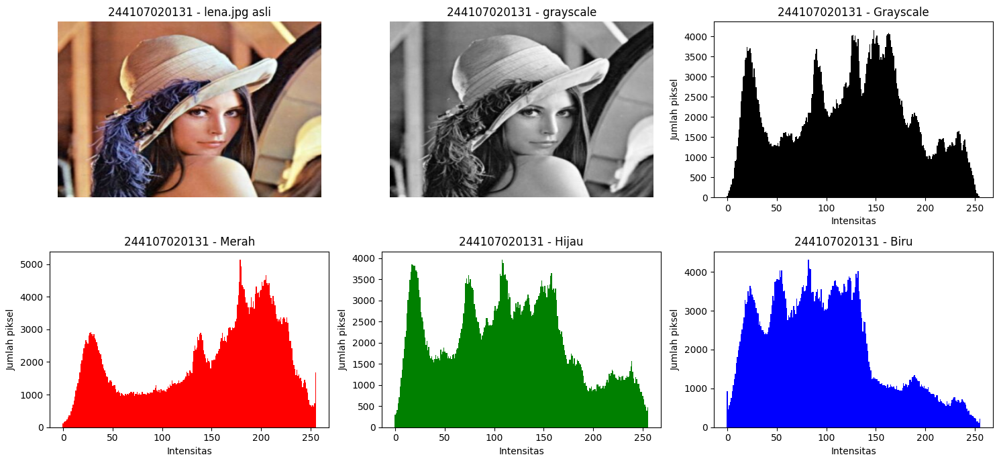

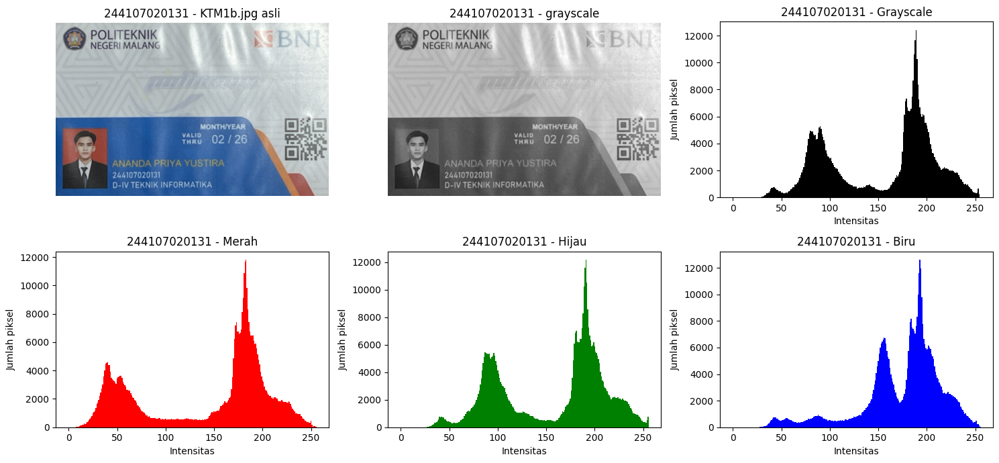

In [28]:
# Tahap 1: citra contoh. Tahap 2: KTM dengan lampu ruangan.
for folder, nama in [(CONTOH, 'lena.jpg'), (BASE, 'KTM1b.jpg')]:
    bgr = cv.imread(folder + '/' + nama)
    bgr = siapkan_gambar(bgr, nama)
    g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    plt.figure(figsize=(15, 7))
    plt.subplot(2, 3, 1)
    plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + nama + ' asli')
    plt.axis('off')
    plt.subplot(2, 3, 2)
    plt.imshow(g, cmap='gray', vmin=0, vmax=255)
    plt.title(NIM + ' - grayscale')
    plt.axis('off')
    kanal = [g, bgr[:, :, 2], bgr[:, :, 1], bgr[:, :, 0]]
    judul = ['Grayscale', 'Merah', 'Hijau', 'Biru']
    warna = ['black', 'red', 'green', 'blue']
    for i in range(4):
        h = histogram_manual(kanal[i])
        plt.subplot(2, 3, i + 3)
        plt.bar(np.arange(256), h, color=warna[i], width=1)
        plt.title(NIM + ' - ' + judul[i])
        plt.xlabel('Intensitas')
        plt.ylabel('Jumlah piksel')
    plt.tight_layout()
    plt.show()


### Pertanyaan E1 nomor 1 — Manual, NumPy, dan OpenCV
Ketiga histogram dibandingkan pada citra contoh dan KTM, termasuk seluruh kanal RGB.


In [29]:
hasil_hist = []
for folder, nama in [(CONTOH, 'lena.jpg'), (BASE, 'KTM1b.jpg')]:
    bgr = cv.imread(folder + '/' + nama)
    bgr = siapkan_gambar(bgr, nama)
    g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    kanal = [g, bgr[:, :, 2], bgr[:, :, 1], bgr[:, :, 0]]
    judul = ['Grayscale', 'Merah', 'Hijau', 'Biru']
    for i in range(4):
        hm = histogram_manual(kanal[i])
        hn = np.histogram(kanal[i], bins=256, range=(0, 256))[0]
        hc = cv.calcHist([kanal[i]], [0], None, [256], [0, 256]).ravel().astype(np.int64)
        beda1 = np.max(np.abs(hm - hn))
        beda2 = np.max(np.abs(hm - hc))
        beda3 = np.max(np.abs(hn - hc))
        assert beda1 == beda2 == beda3 == 0
        hasil_hist.append([nama, judul[i], beda1, beda2, beda3])
display(pd.DataFrame(hasil_hist, columns=['Citra', 'Kanal', 'Manual–NumPy', 'Manual–OpenCV', 'NumPy–OpenCV']))


,Citra,Kanal,Manual–NumPy,Manual–OpenCV,NumPy–OpenCV
0,lena.jpg,Grayscale,0,0,0
1,lena.jpg,Merah,0,0,0
2,lena.jpg,Hijau,0,0,0
3,lena.jpg,Biru,0,0,0
4,KTM1b.jpg,Grayscale,0,0,0
5,KTM1b.jpg,Merah,0,0,0
6,KTM1b.jpg,Hijau,0,0,0
7,KTM1b.jpg,Biru,0,0,0


**Jawaban 1:** Selisih maksimum semuanya **0**. Ketiga cara menghitung frekuensi intensitas yang sama. NumPy dan OpenCV lebih cepat karena tidak memakai perulangan Python per piksel.

### Pertanyaan E1 nomor 2 — Histogram normalisasi dan CDF


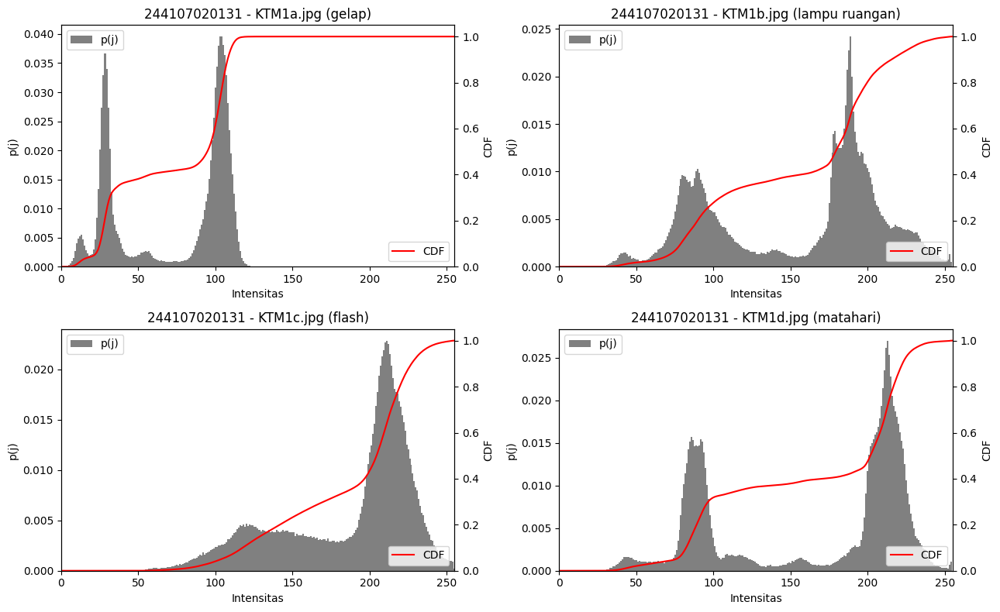

,Citra,Pencahayaan,Rerata intensitas,CDF(127)
0,KTM1a.jpg,gelap,72.44,1.000
1,KTM1b.jpg,lampu ruangan,155.07,0.359
2,KTM1c.jpg,flash,187.02,0.142
3,KTM1d.jpg,matahari,164.70,0.364


In [30]:
# Histogram dinormalisasi dengan membagi jumlah piksel pada tiap intensitas dengan total piksel.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
stat_cahaya = []
for ax, k, kondisi in zip(axes.flat, 'abcd', ['gelap', 'lampu ruangan', 'flash', 'matahari']):
    nama = f'KTM1{k}.jpg'
    bgr = cv.imread(BASE + '/' + nama)
    bgr = siapkan_gambar(bgr, nama)
    g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    p = np.histogram(g, bins=256, range=(0, 256))[0] / g.size
    cdf = np.cumsum(p)
    assert np.isclose(p.sum(), 1) and np.isclose(cdf[-1], 1)
    ax.bar(np.arange(256), p, width=1, color='gray', label='p(j)')
    ax.set(title=NIM + ' - ' + nama + ' (' + kondisi + ')', xlabel='Intensitas', ylabel='p(j)', xlim=(0, 255))
    ax2 = ax.twinx()
    ax2.plot(cdf, color='red', label='CDF')
    ax2.set(ylabel='CDF', ylim=(0, 1.05))
    ax.legend(loc='upper left')
    ax2.legend(loc='lower right')
    stat_cahaya.append([nama, kondisi, round(float(g.mean()), 2), round(float(cdf[127]), 3)])
plt.tight_layout()
plt.show()
display(pd.DataFrame(stat_cahaya, columns=['Citra', 'Pencahayaan', 'Rerata intensitas', 'CDF(127)']))
gelap = min(stat_cahaya, key=lambda r: r[2])
terang = max(stat_cahaya, key=lambda r: r[2])


**Jawaban 2:** Citra paling gelap adalah **KTM1a** (rerata **72,43**), sedangkan paling terang **KTM1c** (rerata **187,01**). CDF citra gelap naik lebih awal karena banyak piksel berintensitas rendah. CDF citra terang lebih banyak naik pada intensitas tinggi. Ruangan gelap mengurangi cahaya yang diterima kamera. Lampu, flash, dan matahari menaikkan intensitas; pada foto flash, pantulan plastik membuat sebagian area terlalu terang.


### Pertanyaan E1 nomor 3 — Jumlah bin


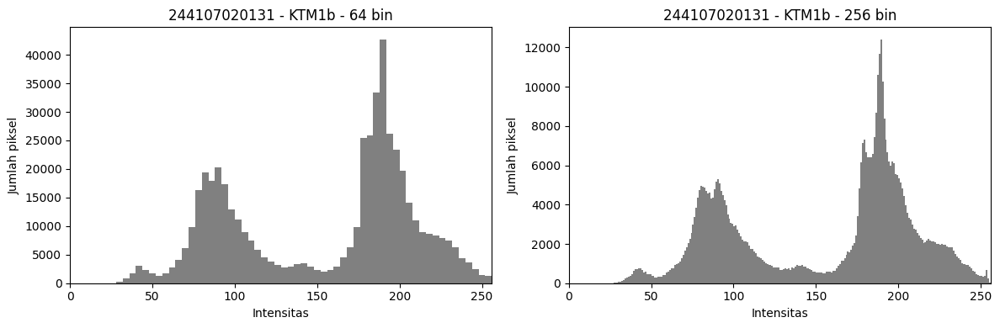

In [31]:
bgr = cv.imread(BASE + '/KTM1b.jpg')
bgr = siapkan_gambar(bgr, 'KTM1b.jpg')
g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, bins in zip(axes, [PARAM['bins'], 256]):
    h, tepi = np.histogram(g, bins=bins, range=(0, 256))
    assert h.sum() == g.size
    ax.bar(tepi[:-1], h, width=np.diff(tepi), align='edge', color='gray')
    ax.set(title=f'{NIM} - KTM1b - {bins} bin', xlabel='Intensitas', ylabel='Jumlah piksel', xlim=(0, 256))
plt.tight_layout()
plt.show()


**Jawaban 3:** Pada 64 bin, setiap bin menggabungkan 4 intensitas. Pola umum masih terlihat, tetapi puncak kecil dan perbedaan antarintensitas berdekatan hilang. Pada 256 bin, setiap intensitas memiliki frekuensinya sendiri.

## E-2. Percobaan histogram equalization
### Praktikum 1–2 — Ekualisasi manual dan `cv.equalizeHist`
Rumus manual mengikuti modul: `round(255 × CDF)`. OpenCV mengurangi CDF minimum sehingga hasil awal bisa berbeda. Versi manual dengan koreksi CDF minimum juga ditampilkan untuk membuktikan penyebabnya.


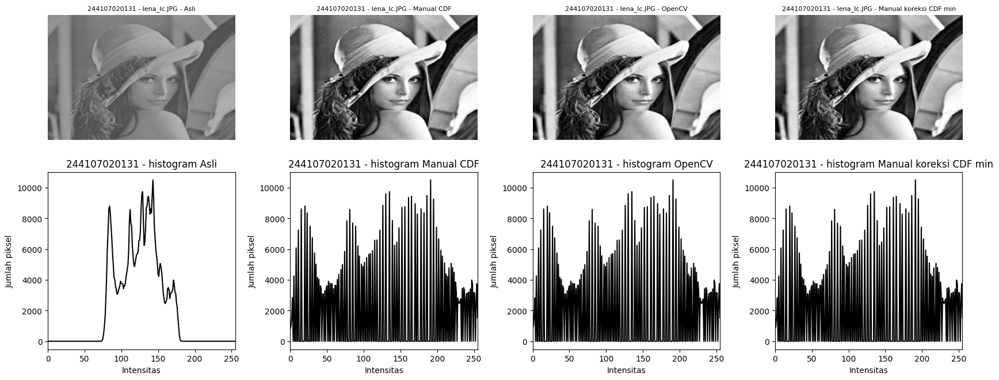

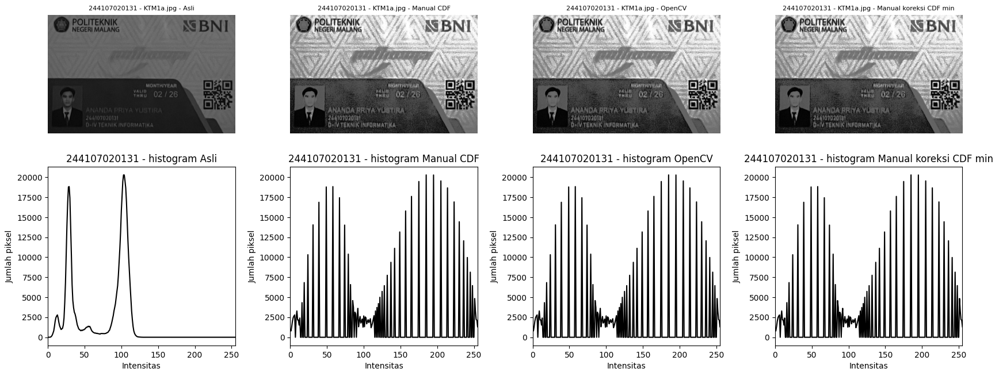

,Citra,Selisih maks. manual–OpenCV,Selisih maks. koreksi–OpenCV
0,lena_lc.JPG,0,0
1,KTM1a.jpg,0,0


In [32]:
# Manual memakai CDF. Versi koreksi mengurangi CDF minimum agar sesuai dengan OpenCV.
def equalization_manual(g, koreksi=False):
    h = histogram_manual(g)
    cdf = np.cumsum(h)
    if koreksi:
        cdf_min = cdf[np.flatnonzero(h)[0]]
        if g.size == cdf_min:
            return g.copy()
        lut = np.rint((cdf - cdf_min) * 255.0 / (g.size - cdf_min))
    else:
        lut = np.rint(cdf * 255.0 / g.size)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[g]
beda_he = []
for folder, nama in [(CONTOH, 'lena_lc.JPG'), (BASE, 'KTM1a.jpg')]:
    bgr = cv.imread(folder + '/' + nama)
    bgr = siapkan_gambar(bgr, nama)
    g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    manual = equalization_manual(g)
    opencv = cv.equalizeHist(g)
    koreksi = equalization_manual(g, koreksi=True)
    beda = int(np.abs(manual.astype(np.int16) - opencv.astype(np.int16)).max())
    beda_koreksi = int(np.abs(koreksi.astype(np.int16) - opencv.astype(np.int16)).max())
    assert beda_koreksi <= 1
    beda_he.append([nama, beda, beda_koreksi])
    daftar = [g, manual, opencv, koreksi]
    judul = ['Asli', 'Manual CDF', 'OpenCV', 'Manual koreksi CDF min']
    fig, axes = plt.subplots(2, 4, figsize=(17, 7))
    for i, (img, label) in enumerate(zip(daftar, judul)):
        axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[0, i].set_title(NIM + ' - ' + nama + ' - ' + label, fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].plot(np.histogram(img, bins=256, range=(0, 256))[0], color='black')
        axes[1, i].set(title=NIM + ' - histogram ' + label, xlabel='Intensitas', ylabel='Jumlah piksel', xlim=(0, 255))
    plt.tight_layout()
    plt.show()
display(pd.DataFrame(beda_he, columns=['Citra', 'Selisih maks. manual–OpenCV', 'Selisih maks. koreksi–OpenCV']))


**Jawaban perbandingan manual–OpenCV:** Selisih maksimum pada `lena_lc.jpg` dan `KTM1a.jpg` sama-sama **1**. Setelah koreksi CDF minimum, selisih menjadi **0**. Rumus modul langsung memakai CDF, sedangkan OpenCV memetakan intensitas terendah yang muncul ke 0. Pembulatan juga dapat menimbulkan selisih satu tingkat.


### Praktikum 3 — Ekualisasi tiap kanal B, G, R
Ekualisasi diterapkan pada `lena.jpg`, kemudian `KTM1d.jpg`.


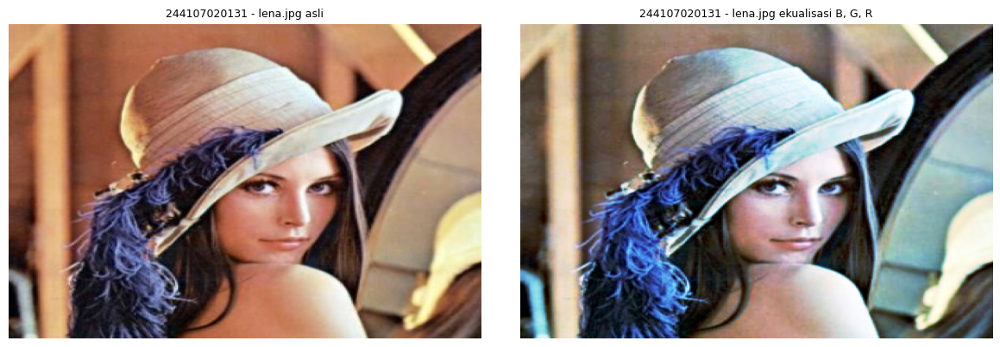

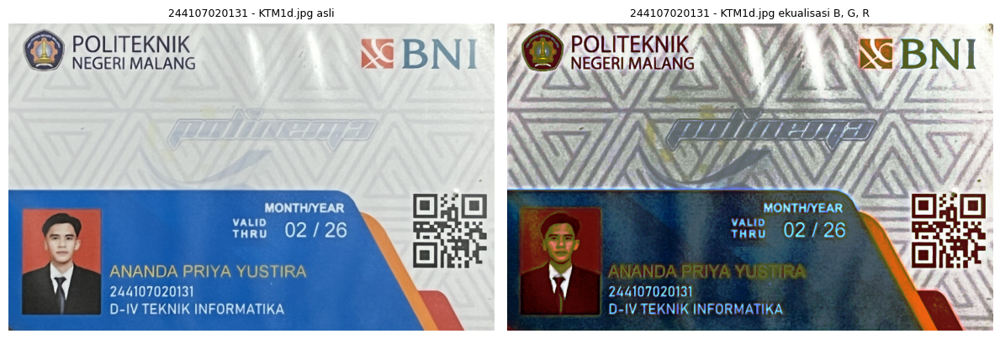

In [33]:
for folder, nama in [(CONTOH, 'lena.jpg'), (BASE, 'KTM1d.jpg')]:
    bgr = cv.imread(folder + '/' + nama)
    bgr = siapkan_gambar(bgr, nama)
    b, g, r = cv.split(bgr)
    b = cv.equalizeHist(b)
    g = cv.equalizeHist(g)
    r = cv.equalizeHist(r)
    he_rgb = cv.merge([b, g, r])
    plt.figure(figsize=(12, 4))
    gambar_plot = [bgr, he_rgb]
    judul_plot = [nama + ' asli', nama + ' ekualisasi B, G, R']
    for i in range(len(gambar_plot)):
        plt.subplot(1, len(gambar_plot), i + 1)
        img_plot = gambar_plot[i]
        if img_plot.ndim == 2:
            plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


**Pengamatan:** Ekualisasi B, G, dan R mengubah keseimbangan warna. Warna kulit pada contoh dan warna biru pada KTM berubah karena setiap kanal memakai pemetaan berbeda.

### Praktikum 4 — Kanal Y, V, dan L serta pengukuran warna


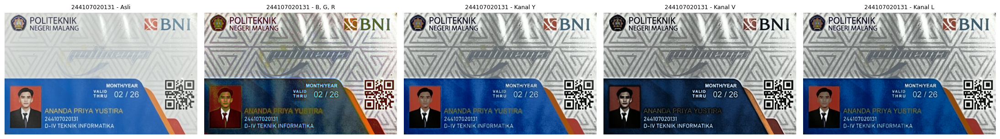

,Cara,Geser Hue (derajat),Rerata kecerahan,Pengamatan
0,Asli,0.00,164.70,Warna masukan
1,"B, G, R",45.00,129.19,Biru dan warna kulit bergeser
2,Kanal Y,1.59,130.01,Biru relatif terjaga; teks cukup terang
3,Kanal V,2.34,118.03,Bagian biru dan nama lebih gelap
4,Kanal L,6.82,122.44,Kontras kuat; sebagian warna berubah


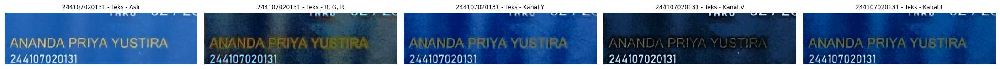

In [34]:
# Setiap cara ditulis terpisah agar perubahan kanal mudah diikuti.
bgr = cv.imread(BASE + '/KTM1d.jpg')
bgr = siapkan_gambar(bgr, 'KTM1d.jpg')
b, g, r = cv.split(bgr)
he_rgb = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
gambar = [bgr, he_rgb, he_y, he_v, he_l]
judul = ['Asli', 'B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
plt.figure(figsize=(22, 4))
gambar_plot = gambar
judul_plot = judul
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean() * 2
catatan = ['Warna masukan', 'Biru dan warna kulit bergeser', 'Biru relatif terjaga; teks cukup terang', 'Bagian biru dan nama lebih gelap', 'Kontras kuat; sebagian warna berubah']
angka_warna = []
for i in range(5):
    hue = geser_hue(bgr, gambar[i])
    terang = cv.cvtColor(gambar[i], cv.COLOR_BGR2GRAY).mean()
    angka_warna.append([judul[i], round(hue, 2), round(terang, 2), catatan[i]])
display(pd.DataFrame(angka_warna, columns=['Cara', 'Geser Hue (derajat)', 'Rerata kecerahan', 'Pengamatan']))
plt.figure(figsize=(22, 3))
gambar_plot = [img[390:510, 175:620] for img in gambar]
judul_plot = ['Teks - ' + k for k in judul]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


**Jawaban 1:** Pergeseran Hue terbesar dihasilkan ekualisasi **B, G, R**, yaitu **44,94°**.

**Jawaban 2:** Konversi ruang warna memakai pembulatan dan pemotongan nilai ke 0–255. Piksel yang menjadi sangat gelap atau kehilangan saturasi juga dapat berubah nilai Hue-nya.

**Jawaban 3:** Saya memilih **kanal Y (YCrCb)**. Pergeseran Hue-nya **1,59°** dengan rerata kecerahan **130,04**. Pergeseran warnanya lebih kecil daripada V/L, dan nama serta NIM pada bagian bawah kiri lebih terang dibanding kanal V.


### Pertanyaan warna nomor 4 — CLAHE pada kanal terang


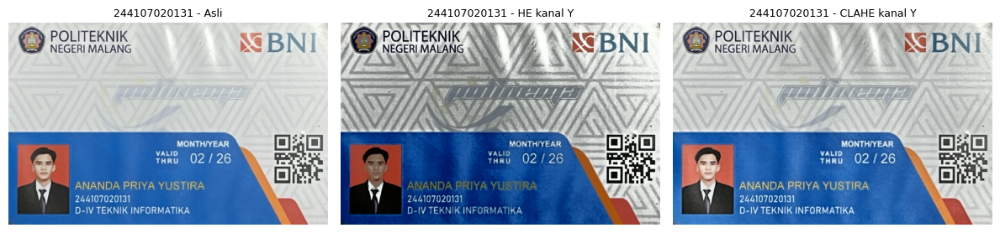

,Cara,Geser Hue (derajat),Rerata kecerahan
0,HE Y,1.59,130.01
1,CLAHE Y,0.59,155.77


In [35]:
clahe_pribadi = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
y_clahe = clahe_pribadi.apply(y)
warna_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)
plt.figure(figsize=(12, 4))
gambar_plot = [bgr, he_y, warna_clahe]
judul_plot = ['Asli', 'HE kanal Y', 'CLAHE kanal Y']
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
baris = []
for nama, img in [('HE Y', he_y), ('CLAHE Y', warna_clahe)]:
    hue = geser_hue(bgr, img)
    terang = cv.cvtColor(img, cv.COLOR_BGR2GRAY).mean()
    baris.append([nama, round(hue, 2), round(terang, 2)])
display(pd.DataFrame(baris, columns=['Cara', 'Geser Hue (derajat)', 'Rerata kecerahan']))


**Jawaban 4:** HE kanal Y menghasilkan pergeseran Hue **1,59°** dan rerata kecerahan **130,04**. CLAHE kanal Y menghasilkan **0,59°** dan **155,75**. Pada foto ini, CLAHE mengubah warna lebih sedikit dan memberikan hasil lebih terang. Kontras diperbaiki per area sehingga detail teks terlihat lebih merata.


### Pertanyaan E2 nomor 1 — Ekualisasi global dan PSNR
Citra asli, hasil manual, OpenCV, dan histogram KTM1a sudah ditampilkan pada praktikum 1–2.


In [36]:
bgr = cv.imread(BASE + '/KTM1a.jpg')
bgr = siapkan_gambar(bgr, 'KTM1a.jpg')
g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else float(10 * np.log10(255.0 ** 2 / mse))
psnr_manual = psnr(g, equalization_manual(g))
psnr_cv = psnr(g, cv.equalizeHist(g))
display(pd.DataFrame([['Asli dengan dirinya sendiri', '∞'], ['Manual', f'{psnr_manual:.2f}'], ['OpenCV', f'{psnr_cv:.2f}']], columns=['Perbandingan terhadap asli', 'PSNR (dB)']))


,Perbandingan terhadap asli,PSNR (dB)
0,Asli dengan dirinya sendiri,∞
1,Manual,11.04
2,OpenCV,11.04


**Jawaban 1:** PSNR manual dan OpenCV sama-sama **11,04 dB**. Nilainya turun dari tak hingga karena intensitas hasil sengaja diubah dari citra asli. Perubahan ini memperjelas kontras teks walaupun selisih piksel membesar. Jadi, PSNR terhadap citra gelap asli tidak cukup untuk menilai keterbacaan. Nama dan NIM perlu diperiksa langsung.


### Pertanyaan E2 nomor 2a — CLAHE dan ekualisasi global


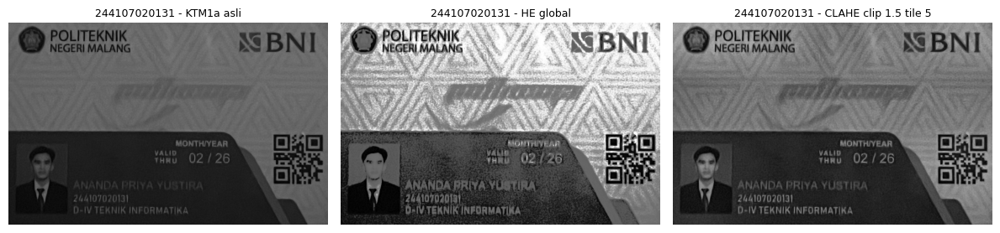

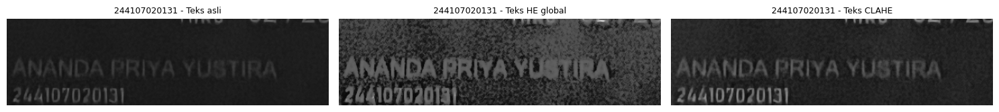

In [37]:
bgr = cv.imread(BASE + '/KTM1a.jpg')
bgr = siapkan_gambar(bgr, 'KTM1a.jpg')
g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
global_he = cv.equalizeHist(g)
lokal_he = clahe_pribadi.apply(g)
plt.figure(figsize=(12, 4))
gambar_plot = [g, global_he, lokal_he]
judul_plot = ['KTM1a asli', 'HE global', f"CLAHE clip {PARAM['clip']} tile {PARAM['tile']}"]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(15, 3))
gambar_plot = [img[390:510, 175:620] for img in [g, global_he, lokal_he]]
judul_plot = ['Teks asli', 'Teks HE global', 'Teks CLAHE']
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


**Jawaban 2a:** Pada foto gelap ini, ekualisasi global membuat nama dan NIM lebih terang sehingga lebih mudah terbaca. CLAHE 1,5 memperbaiki kontras lokal, tetapi bagian teks masih relatif gelap. Potongan nama/NIM di atas menjadi dasar perbandingan.

### Pertanyaan E2 nomor 2b — Tiga nilai clipLimit lain
Nilai utama 1,5 dibandingkan dengan 1,0; 2,0; dan 2,5. Ukuran tile tetap (5,5).


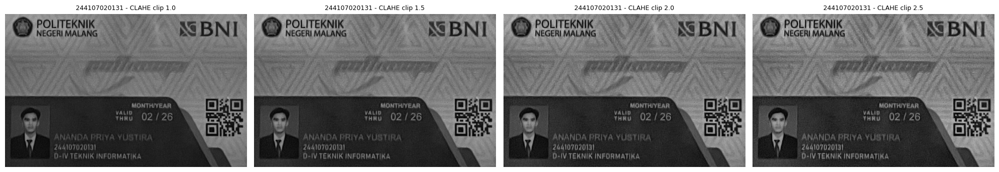

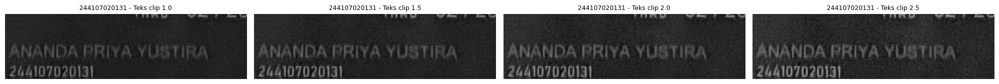

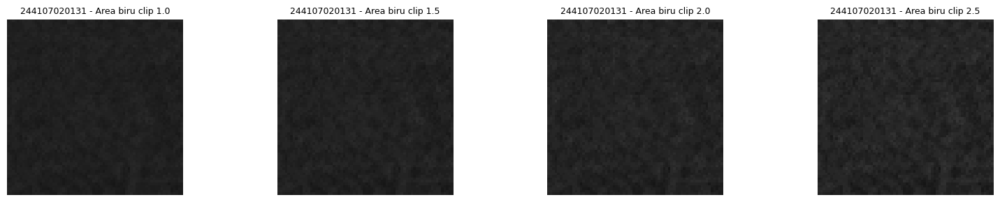

,clipLimit,Rerata kecerahan
0,1.0,85.26
1,1.5,88.84
2,2.0,91.67
3,2.5,94.14


In [38]:
clips = [1.0, PARAM['clip'], 2.0, 2.5]
uji_clahe = []
baris = []
for clip in clips:
    clahe = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe.apply(g)
    uji_clahe.append(hasil)
    baris.append([clip, round(hasil.mean(), 2)])
plt.figure(figsize=(20, 4))
gambar_plot = uji_clahe
judul_plot = [f'CLAHE clip {c:.1f}' for c in clips]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(20, 3))
gambar_plot = [img[390:510, 175:620] for img in uji_clahe]
judul_plot = [f'Teks clip {c:.1f}' for c in clips]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(16, 3))
gambar_plot = [img[480:550, 600:670] for img in uji_clahe]
judul_plot = [f'Area biru clip {c:.1f}' for c in clips]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
display(pd.DataFrame(baris, columns=['clipLimit', 'Rerata kecerahan']))


**Jawaban 2b:** Saya memilih **clipLimit 2,5** dari nilai yang diuji karena nama dan NIM lebih jelas dibanding 1,0–2,0. Bintik/tekstur juga makin terlihat di area biru kosong sebelah kanan teks saat clipLimit dinaikkan. Nilai ini dipilih dari potongan teks, bukan hanya dari rerata kecerahan.

## E-3. Tugas praktikum dithering
### Fungsi Floyd–Steinberg
Pemindaian dari kiri ke kanan, lalu atas ke bawah. Bobot: kanan 7/16, kiri bawah 3/16, bawah 5/16, dan kanan bawah 1/16. Citra kerja memakai float agar tidak overflow. Nilai tetangga dibatasi ke 0–255 sesuai catatan implementasi modul; piksel di luar citra dilewati.


In [39]:
# Citra kerja memakai float agar penambahan error tidak overflow.
def floyd_steinberg(g, L=2):
    img = g.astype(np.float64).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            for dy, dx, bobot in [(0, 1, 7), (1, -1, 3), (1, 0, 5), (1, 1, 1)]:
                ny, nx = (y + dy, x + dx)
                if 0 <= ny < H and 0 <= nx < W:
                    nilai = img[ny, nx] + error * bobot / 16
                    img[ny, nx] = min(255.0, max(0.0, nilai))
    hasil = np.rint(np.clip(img, 0, 255)).astype(np.uint8)
    palet = np.rint(np.linspace(0, 255, L)).astype(np.uint8)
    assert np.isin(hasil, palet).all()
    return hasil


### Praktikum 1 — Dithering langsung
Contoh warna memakai 2 level per kanal (total paling banyak 8 warna), seperti ilustrasi modul. Contoh grayscale juga diperlihatkan. KTM1b memakai **L = 8** dari NIM untuk grayscale maupun setiap kanal warna.


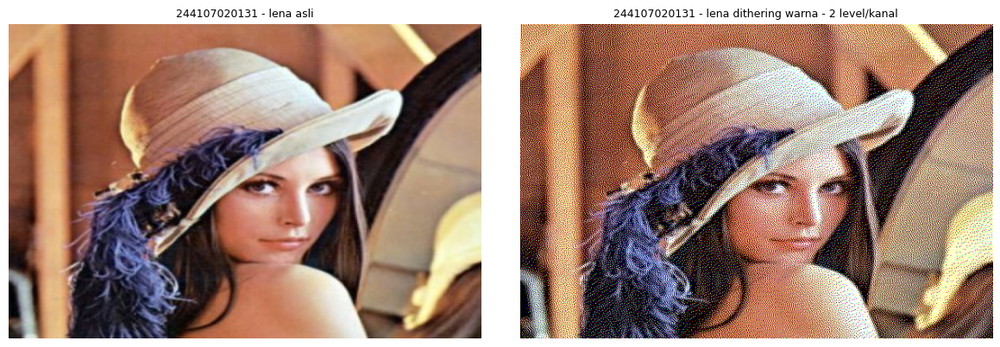

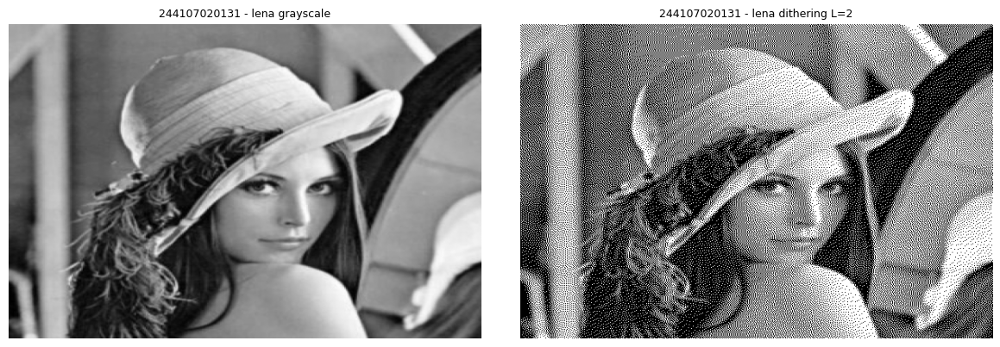

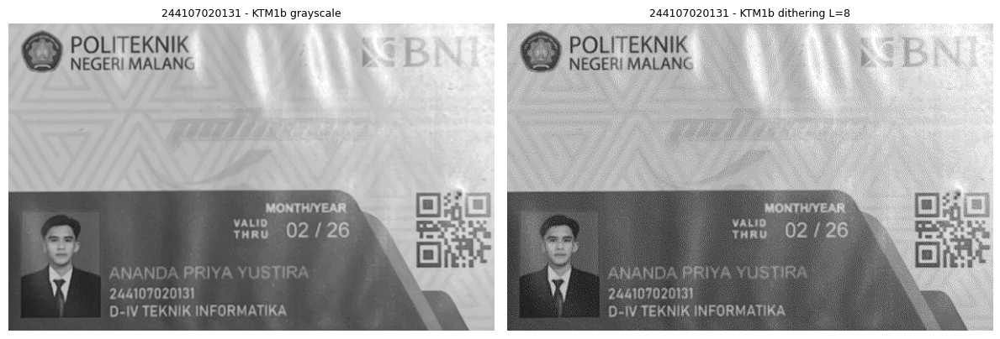

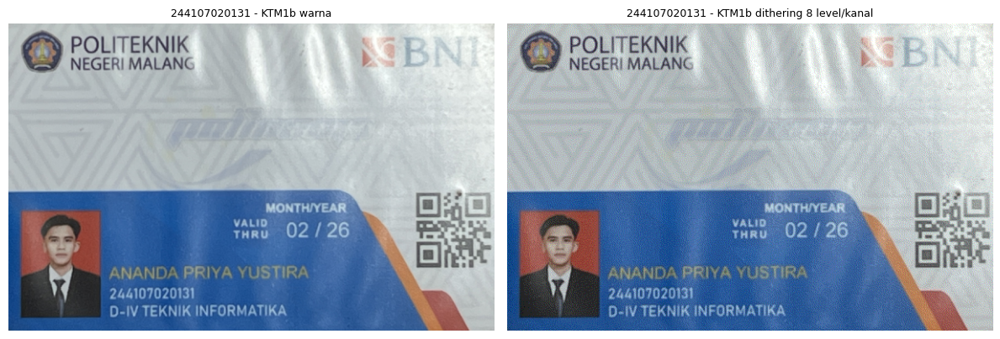

Level grayscale KTM1b: [  0  36  73 109 146 182 219 255]
Jumlah warna contoh: 8


In [40]:
lena = cv.imread(CONTOH + '/lena.jpg')
lena = siapkan_gambar(lena, 'lena.jpg')
lena_k = cv.resize(lena, (600, 400), interpolation=cv.INTER_AREA)
ktmb = cv.imread(BASE + '/KTM1b.jpg')
ktmb = siapkan_gambar(ktmb, 'KTM1b.jpg')
ktmb_k = cv.resize(ktmb, (600, 380), interpolation=cv.INTER_AREA)
lena_g = cv.cvtColor(lena_k, cv.COLOR_BGR2GRAY)
ktmb_g = cv.cvtColor(ktmb_k, cv.COLOR_BGR2GRAY)
d_lena_w = cv.merge([floyd_steinberg(lena_k[:, :, 0], 2), floyd_steinberg(lena_k[:, :, 1], 2), floyd_steinberg(lena_k[:, :, 2], 2)])
d_lena_g = floyd_steinberg(lena_g, 2)
plt.figure(figsize=(12, 4))
gambar_plot = [lena_k, d_lena_w]
judul_plot = ['lena asli', 'lena dithering warna - 2 level/kanal']
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 4))
gambar_plot = [lena_g, d_lena_g]
judul_plot = ['lena grayscale', 'lena dithering L=2']
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
d_ktmb_g = floyd_steinberg(ktmb_g, PARAM['L'])
d_ktmb_w = cv.merge([floyd_steinberg(ktmb_k[:, :, 0], PARAM['L']), floyd_steinberg(ktmb_k[:, :, 1], PARAM['L']), floyd_steinberg(ktmb_k[:, :, 2], PARAM['L'])])
plt.figure(figsize=(12, 4))
gambar_plot = [ktmb_g, d_ktmb_g]
judul_plot = ['KTM1b grayscale', f"KTM1b dithering L={PARAM['L']}"]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 4))
gambar_plot = [ktmb_k, d_ktmb_w]
judul_plot = ['KTM1b warna', f"KTM1b dithering {PARAM['L']} level/kanal"]
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
print('Level grayscale KTM1b:', np.unique(d_ktmb_g))
print('Jumlah warna contoh:', len(np.unique(d_lena_w.reshape(-1, 3), axis=0)))
assert len(np.unique(d_lena_w.reshape(-1, 3), axis=0)) <= 8
assert len(np.unique(d_ktmb_g)) <= PARAM['L']


**Pengamatan praktikum 1:** Dithering mengurangi level intensitas, tetapi pola piksel membantu mempertahankan kesan gradasi. Pada grayscale KTM1b hanya ada 8 level; pada citra warna ada paling banyak 8³ = 512 kombinasi warna. Teks masih terlihat, tetapi tepinya lebih berbintik.

### Praktikum 2 — Grayscale → ekualisasi → dithering
Hasil dibandingkan dengan dithering langsung. Contoh `lena_lc.jpg` memakai L=2, kemudian KTM1a memakai L=8.


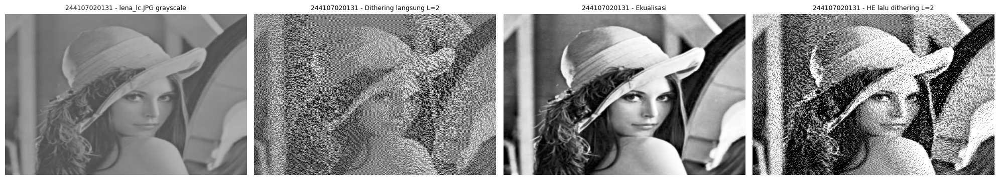

lena_lc.JPG | langsung: [  0 255] | setelah HE: [  0 255]


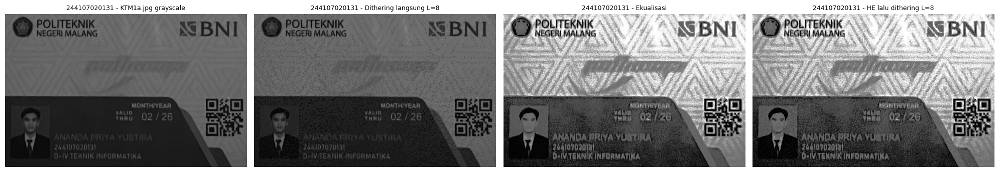

KTM1a.jpg | langsung: [  0  36  73 109 146] | setelah HE: [  0  36  73 109 146 182 219 255]


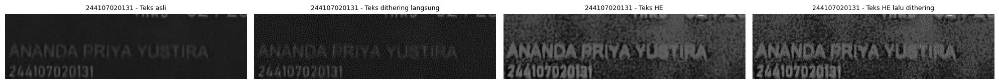

In [42]:
for folder, nama, L in [(CONTOH, 'lena_lc.JPG', 2), (BASE, 'KTM1a.jpg', PARAM['L'])]:
    bgr = cv.imread(folder + '/' + nama)
    bgr = siapkan_gambar(bgr, nama)
    tinggi, lebar = bgr.shape[:2]
    bgr = cv.resize(bgr, (600, round(tinggi * 600 / lebar)), interpolation=cv.INTER_AREA)
    g_k = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    he = cv.equalizeHist(g_k)
    langsung = floyd_steinberg(g_k, L)
    setelah_he = floyd_steinberg(he, L)
    plt.figure(figsize=(20, 4))
    gambar_plot = [g_k, langsung, he, setelah_he]
    judul_plot = [nama + ' grayscale', f'Dithering langsung L={L}', 'Ekualisasi', f'HE lalu dithering L={L}']
    for i in range(len(gambar_plot)):
        plt.subplot(1, len(gambar_plot), i + 1)
        img_plot = gambar_plot[i]
        if img_plot.ndim == 2:
            plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(nama, '| langsung:', np.unique(langsung), '| setelah HE:', np.unique(setelah_he))
plt.figure(figsize=(20, 3))
gambar_plot = [img[260:340, 117:413] for img in [g_k, langsung, he, setelah_he]]
judul_plot = ['Teks asli', 'Teks dithering langsung', 'Teks HE', 'Teks HE lalu dithering']
for i in range(len(gambar_plot)):
    plt.subplot(1, len(gambar_plot), i + 1)
    img_plot = gambar_plot[i]
    if img_plot.ndim == 2:
        plt.imshow(img_plot, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv.cvtColor(img_plot, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_plot[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


**Jawaban praktikum 2:** Urutan **grayscale → histogram equalization → dithering** membuat nama dan NIM pada KTM1a lebih terbaca. Ekualisasi memperlebar sebaran intensitas sebelum dikurangi menjadi 8 level. Dithering langsung mempertahankan kondisi gelap sehingga teks kurang jelas. Bintik pada hasil dithering adalah pola kuantisasi, bukan detail baru.

### Perhitungan manual satu langkah Floyd–Steinberg
Satu piksel interior dari KTM1b digunakan untuk perhitungan manual. Diasumsikan nilai pada patch ini adalah nilai kerja saat piksel pusat akan diproses. Ini verifikasi satu langkah, bukan penelusuran seluruh gambar.


In [43]:
# Verifikasi satu langkah pada patch 3 x 3 dari KTM1b.
x, y = (200, 420)
bgr = cv.imread(BASE + '/KTM1b.jpg')
bgr = siapkan_gambar(bgr, 'KTM1b.jpg')
g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
patch = g[y - 1:y + 2, x - 1:x + 2].astype(np.float64)
lama = float(patch[1, 1])
step = 255.0 / (PARAM['L'] - 1)
baru = float(np.round(lama / step) * step)
error = lama - baru
print('Patch sebelum:\n', patch)
print(f"L={PARAM['L']}; step=255/7={step:.6f}; lama={lama}; baru={baru:.6f}; error={error:.6f}")
manual = patch.copy()
manual[1, 1] = baru
manual[1, 2] = np.clip(patch[1, 2] + error * 7 / 16, 0, 255)
manual[2, 0] = np.clip(patch[2, 0] + error * 3 / 16, 0, 255)
manual[2, 1] = np.clip(patch[2, 1] + error * 5 / 16, 0, 255)
manual[2, 2] = np.clip(patch[2, 2] + error * 1 / 16, 0, 255)
program = patch.copy()
program[1, 1] = baru
for dy, dx, bobot in [(0, 1, 7), (1, -1, 3), (1, 0, 5), (1, 1, 1)]:
    program[1 + dy, 1 + dx] = np.clip(program[1 + dy, 1 + dx] + error * bobot / 16, 0, 255)
assert np.allclose(manual, program)
baris = []
for label, py, px, bobot in [('Kanan', 1, 2, 7), ('Kiri bawah', 2, 0, 3), ('Bawah', 2, 1, 5), ('Kanan bawah', 2, 2, 1)]:
    baris.append([label, patch[py, px], f'{bobot}/16', f'{error * bobot / 16:.6f}', f'{manual[py, px]:.6f}'])
display(pd.DataFrame(baris, columns=['Tetangga', 'Nilai lama', 'Bobot', 'Tambahan error', 'Nilai baru']))
print('Patch setelah satu langkah:\n', np.round(program, 6))
print('Selisih maksimum manual–program:', np.max(np.abs(manual - program)))


Patch sebelum:
 [[84. 85. 88.]
 [84. 83. 85.]
 [85. 85. 84.]]
L=8; step=255/7=36.428571; lama=83.0; baru=72.857143; error=10.142857


,Tetangga,Nilai lama,Bobot,Tambahan error,Nilai baru
0,Kanan,85.0,7/16,4.437500,89.437500
1,Kiri bawah,85.0,3/16,1.901786,86.901786
2,Bawah,85.0,5/16,3.169643,88.169643
3,Kanan bawah,84.0,1/16,0.633929,84.633929


Patch setelah satu langkah:
 [[84.       85.       88.      ]
 [84.       72.857143 89.4375  ]
 [86.901786 88.169643 84.633929]]
Selisih maksimum manual–program: 0.0


**Jawaban:** Piksel **83** dipetakan ke **72,857143**, sehingga error-nya **10,142857**. Error dibagikan ke kanan, kiri bawah, bawah, dan kanan bawah sesuai tabel. Jumlah bobot **16/16 = 1**. Selisih perhitungan manual dengan program **0**, sehingga satu langkah perhitungannya sesuai.
